In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import restoration, exposure, color, util
from skimage.filters import unsharp_mask
from skimage.morphology import disk
from skimage.filters import rank


def show_images(original, enhanced, title_original='Original', title_enhanced='Enhanced'):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(title_original)
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
    plt.title(title_enhanced)
    plt.axis('off')
    plt.show()

In [62]:
import cv2
import numpy as np

def enhance_blurred(image_path, sigma=1.0, amount=1.5):
    """
    Memperbaiki gambar blur menggunakan teknik Unsharp Masking.
    Formula: result = original + (original - blurred) * amount
    """
    img = cv2.imread(image_path)

    blurred = cv2.GaussianBlur(img, (0, 0), sigma)

    enhanced = cv2.addWeighted(img, 1.0 + amount, blurred, -amount, 0)

    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

    return enhanced


In [63]:
def enhance_dark(image_path, gamma=0.5):
    """Brighten a dark image using gamma correction."""
    img = cv2.imread(image_path)
    img_norm = img / 255.0
    enhanced = np.power(img_norm, gamma)
    enhanced = (enhanced * 255).astype(np.uint8)
    return enhanced

In [64]:
def enhance_bright(image_path, gamma=2.0):
    """Darken an overexposed image using gamma correction."""
    img = cv2.imread(image_path)
    img_norm = img / 255.0
    enhanced = np.power(img_norm, gamma)
    enhanced = (enhanced * 255).astype(np.uint8)
    return enhanced

In [65]:
def enhance_low_contrast(image_path, clip_limit=2.0, tile_grid_size=(8,8)):
    """Improve contrast using CLAHE."""
    img = cv2.imread(image_path)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l)
    lab_enhanced = cv2.merge((l_enhanced, a, b))
    enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
    return enhanced

In [66]:
def enhance_noisy(image_path, method='nlm', strength=10):
    """Denoise image using Non-local Means or Median filter."""
    img = cv2.imread(image_path)
    if method == 'nlm':
        enhanced = cv2.fastNlMeansDenoisingColored(img, None, strength, strength, 7, 21)
    elif method == 'median':
        enhanced = cv2.medianBlur(img, 5)
    else:
        enhanced = img
    return enhanced

In [67]:
def enhance_uneven_illumination(image_path, kernel_size=50):
    """Correct uneven illumination using background subtraction."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    background = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)
    background = np.where(background == 0, 1, background)
    corrected_gray = (gray / background * 255).clip(0,255).astype(np.uint8)
    factor = corrected_gray.astype(float) / gray.astype(float)
    factor = np.clip(factor, 0, 3)
    enhanced = np.zeros_like(img)
    for i in range(3):
        enhanced[:,:,i] = (img[:,:,i] * factor).clip(0,255).astype(np.uint8)
    return enhanced

In [68]:
def enhance_too_sharp(image_path, sigma=1.0):
    """Soften an over-sharpened image by applying slight Gaussian blur."""
    img = cv2.imread(image_path)
    enhanced = cv2.GaussianBlur(img, (0,0), sigma)
    return enhanced

In [69]:
def enhance_low_resolution(image_path, scale=2):
    """Increase resolution using bicubic interpolation."""
    img = cv2.imread(image_path)
    height, width = img.shape[:2]
    new_dim = (width * scale, height * scale)
    enhanced = cv2.resize(img, new_dim, interpolation=cv2.INTER_CUBIC)
    return enhanced

In [70]:
def enhance_color_cast(image_path, method='grayworld'):
    """Correct color cast using white balancing."""
    img = cv2.imread(image_path)
    if method == 'grayworld':
        avg_b = np.mean(img[:,:,0])
        avg_g = np.mean(img[:,:,1])
        avg_r = np.mean(img[:,:,2])
        target = (avg_b + avg_g + avg_r) / 3
        scale_b = target / avg_b if avg_b != 0 else 1
        scale_g = target / avg_g if avg_g != 0 else 1
        scale_r = target / avg_r if avg_r != 0 else 1
        enhanced = img.copy()
        enhanced[:,:,0] = np.clip(img[:,:,0] * scale_b, 0, 255).astype(np.uint8)
        enhanced[:,:,1] = np.clip(img[:,:,1] * scale_g, 0, 255).astype(np.uint8)
        enhanced[:,:,2] = np.clip(img[:,:,2] * scale_r, 0, 255).astype(np.uint8)
    elif method == 'histmatch':
        enhanced = img
    return enhanced

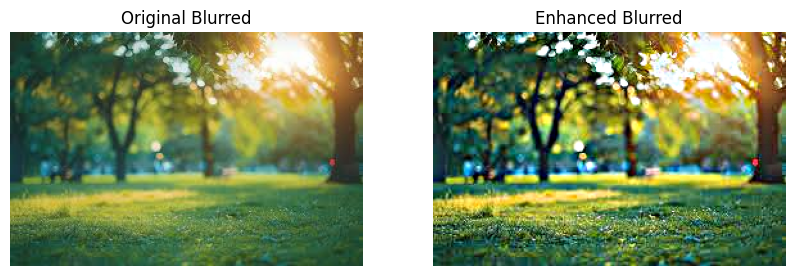

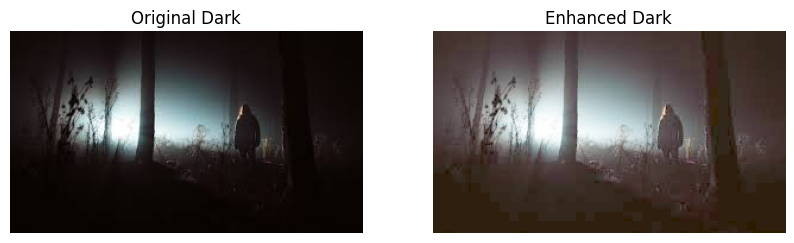

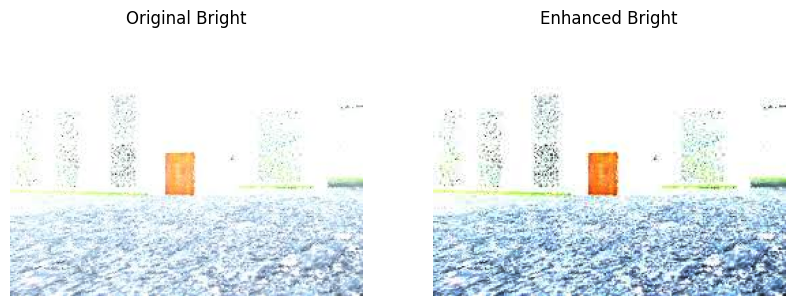

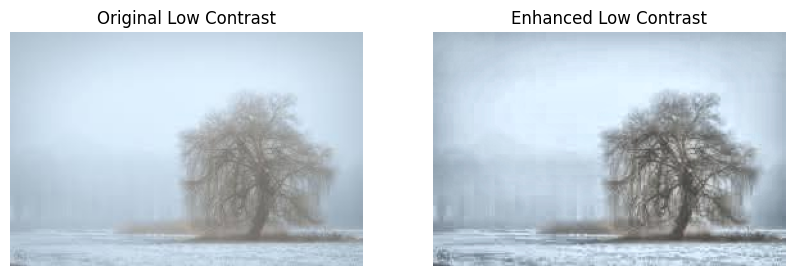

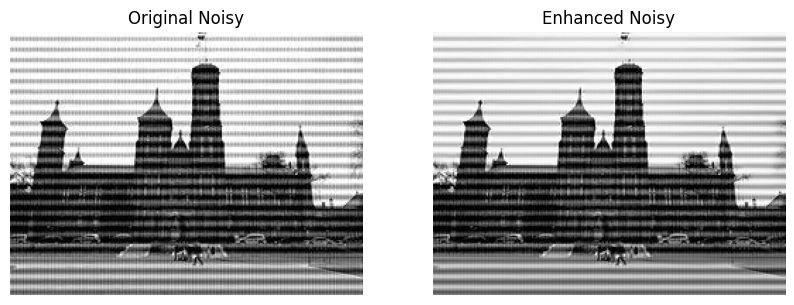

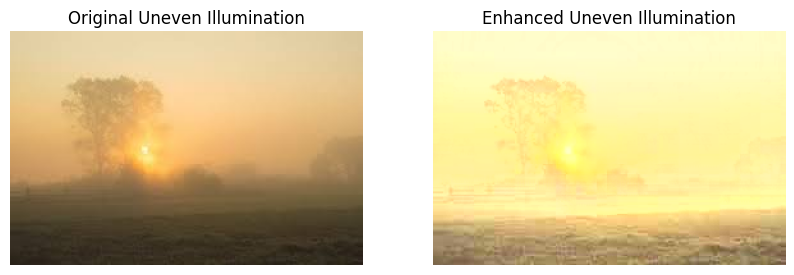

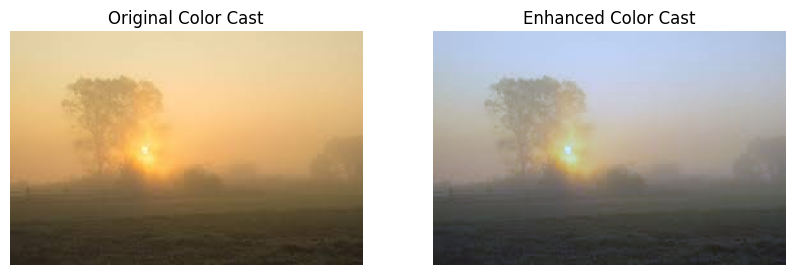

In [60]:
if __name__ == "__main__":

     # enhance a blur image
    img_blur = enhance_blurred('/content/blur2.jpg', sigma=5, amount=1.5)
    cv2.imwrite('blur_enhanced.jpg', img_blur)

    # enhance a dark image
    img_dark = enhance_dark('/content/dark_img.jpg', gamma=0.5)
    cv2.imwrite('dark_enhanced.jpg', img_dark)

    # enhance an overexposed image
    img_bright = enhance_bright('/content/brigth_img.jpg', gamma=2.0)
    cv2.imwrite('bright_enhanced.jpg', img_bright)

    # enhance low contrast
    img_lowcon = enhance_low_contrast('/content/low_contrast_img.jpg', clip_limit=2.0, tile_grid_size=(8,8))
    cv2.imwrite('contrast_enhanced.jpg', img_lowcon)

    # enhance noisy image
    img_noisy = enhance_noisy('/content/noisy_img.jpg', method='nlm', strength=10)
    cv2.imwrite('noisy_enhanced.jpg', img_noisy)

    # enhance uneven illumination
    img_uneven_illum = enhance_uneven_illumination('/content/hazy_img.jpg', kernel_size=51)
    cv2.imwrite('uneven_illum_enhanced.jpg', img_uneven_illum)

    # enhance color cast
    img_color_cast = enhance_color_cast('/content/hazy_img.jpg', method='grayworld')
    cv2.imwrite('color_cast_enhanced.jpg', img_color_cast)

    # Display images
    ori_blur = cv2.imread('/content/blur2.jpg')
    show_images(ori_blur, img_blur, 'Original Blurred', 'Enhanced Blurred')

    ori_dark = cv2.imread('/content/dark_img.jpg')
    show_images(ori_dark, img_dark, 'Original Dark', 'Enhanced Dark')

    ori_bright = cv2.imread('/content/brigth_img.jpg')
    show_images(ori_bright, img_bright, 'Original Bright', 'Enhanced Bright')

    ori_lowcon = cv2.imread('/content/low_contrast_img.jpg')
    show_images(ori_lowcon, img_lowcon, 'Original Low Contrast', 'Enhanced Low Contrast')

    ori_noisy = cv2.imread('/content/noisy_img.jpg')
    show_images(ori_noisy, img_noisy, 'Original Noisy', 'Enhanced Noisy')

    ori_uneven_illum = cv2.imread('/content/hazy_img.jpg')
    show_images(ori_uneven_illum, img_uneven_illum, 'Original Uneven Illumination', 'Enhanced Uneven Illumination')

    ori_color_cast = cv2.imread('/content/hazy_img.jpg')
    show_images(ori_color_cast, img_color_cast, 'Original Color Cast', 'Enhanced Color Cast')